In [1]:
! uv pip install ../.[training] --no-deps

Using Python 3.12.10 environment at: /home/dmp131/anaconda3/envs/cshark
Resolved 1 package in 6ms                                            
   Building cshark @ file:///home/dmp131/C.Shark                       
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
      Built cshark

In [2]:
import os
# force CPU
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from IPython.display import Image

def display_images(image_path1, image_path2):
        # read images
        img_A = mpimg.imread(image_path1)
        img_B = mpimg.imread(image_path2)

        # pad top with white space
        larger = max(img_A.shape[0], img_B.shape[0])
        img_A = np.pad(img_A, ((larger - img_A.shape[0], 0), (0, 0), (0, 0)), mode='constant', constant_values=1)
        img_B = np.pad(img_B, ((larger - img_B.shape[0], 0), (0, 0), (0, 0)), mode='constant', constant_values=1)

        # stack
        img = np.concatenate((img_A, img_B), axis=1)
        # save tmp image
        tmp_path = 'tmp.png'
        plt.imsave(tmp_path, img)
        return Image(tmp_path, width=600)

In [ ]:
chrom = 'chr11'
start = 31000000
region = 'chr11:31373941-33024355'
celltype = 'hESC_WT_5kb_norm_10'
checkpoint = '/mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/hESC_5kb_deeploop_8_tracks_in.ckpt'
ctcf = f'ctcf=/mnt/jinstore/JinLab02/dmp131/C.Shark/cshark_data/data/hg19/{celltype}/genomic_features/ctcf.bw'
atac = f'atac=/mnt/jinstore/JinLab02/dmp131/C.Shark/cshark_data/data/hg19/{celltype}/genomic_features/atac.bw'
rad21 = f'rad21=/mnt/jinstore/JinLab02/dmp131/C.Shark/cshark_data/data/hg19/{celltype}/genomic_features/rad21.bw'
h3k27ac = f'h3k27ac=/mnt/jinstore/JinLab02/dmp131/C.Shark/cshark_data/data/hg19/{celltype}/genomic_features/h3k27ac.bw'
h3k4me3 = f'h3k4me3=/mnt/jinstore/JinLab02/dmp131/C.Shark/cshark_data/data/hg19/{celltype}/genomic_features/h3k4me3.bw'
h3k9me3 = f'h3k9me3=/mnt/jinstore/JinLab02/dmp131/C.Shark/cshark_data/data/hg19/{celltype}/genomic_features/h3k9me3.bw'
h3k36me3 = f'h3k36me3=/mnt/jinstore/JinLab02/dmp131/C.Shark/cshark_data/data/hg19/{celltype}/genomic_features/h3k36me3.bw'
h3k27me3 = f'h3k27me3=/mnt/jinstore/JinLab02/dmp131/C.Shark/cshark_data/data/hg19/{celltype}/genomic_features/h3k27me3.bw'  

In [5]:
! python ../src/cshark/inference/perturb.py \
    --celltype $celltype \
    --outname baseline \
    --chr $chrom \
    --start $start \
    --model $checkpoint \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --latent_size 256 \
    --seq-filter-size 15 \
    --no-recon \
    --region $region \
    --min-val-pred 0.5 \
    --max-val-pred 2.0 \
    --plot-bigwigs ctcf atac \
    --bigwigs $ctcf \
              $atac \
                $rad21 \
                $h3k27ac \
                $h3k4me3 \
                $h3k9me3 \
                $h3k36me3 \
                $h3k27me3 \
    --silent

6


### WT Prediction

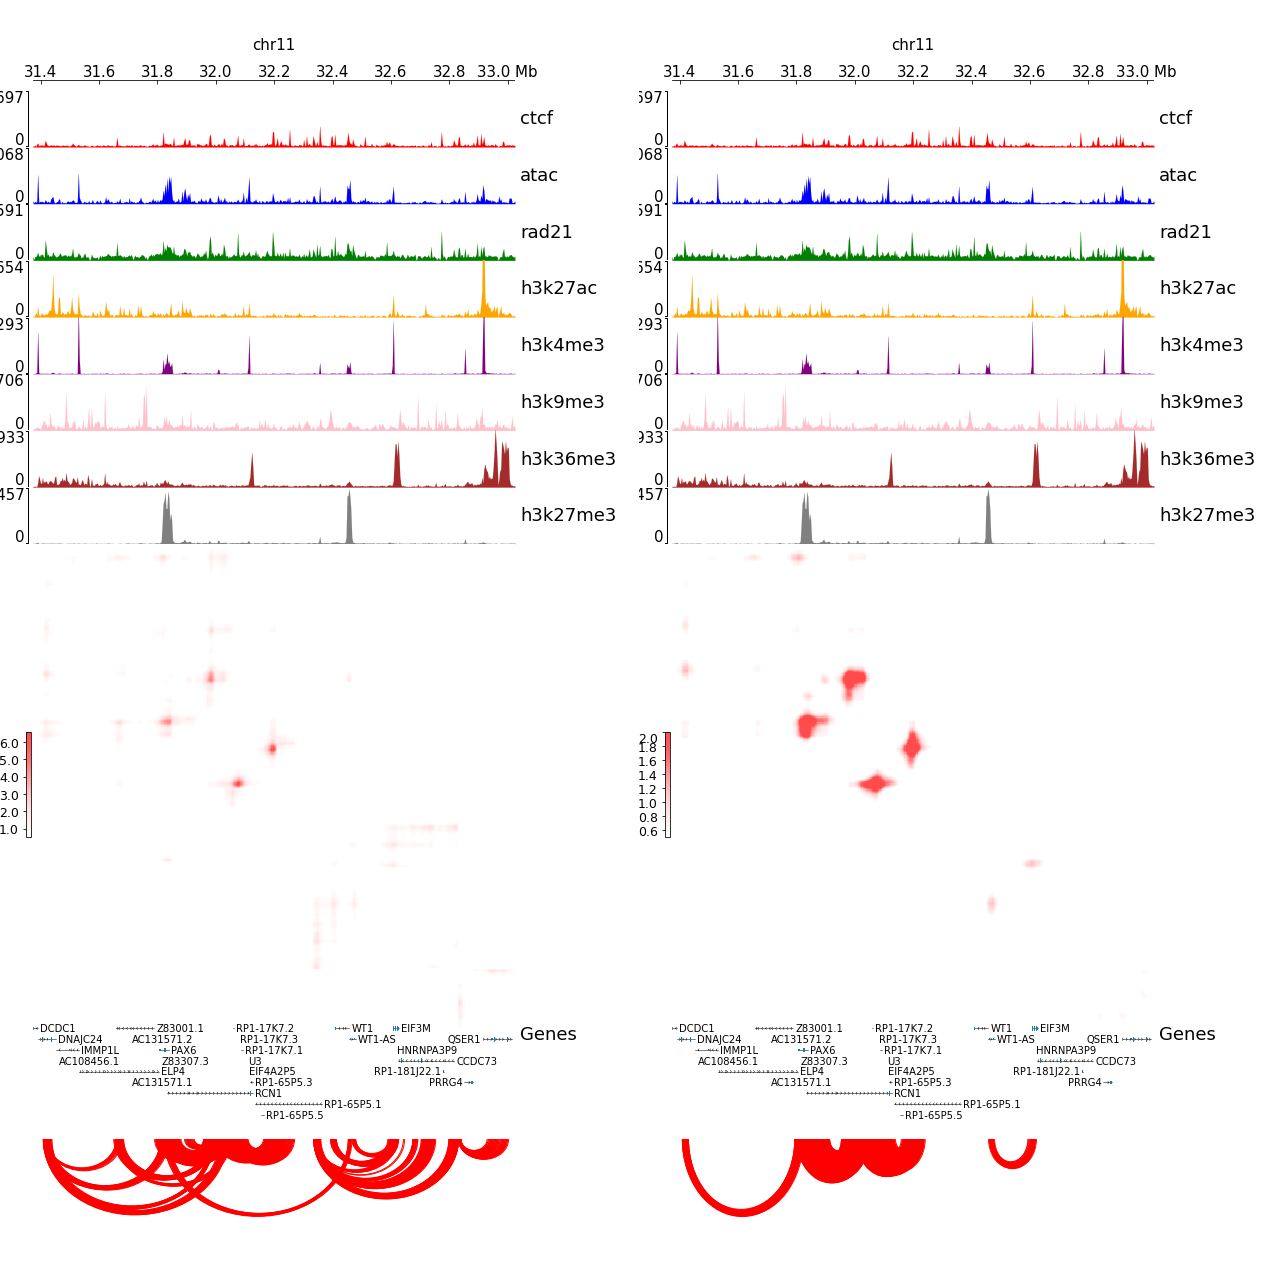

In [6]:
display_images(f'outputs/baseline_{celltype}_{chrom}_{start}_ctcf_true_tracks.png', 
               f'outputs/baseline_{celltype}_{chrom}_{start}_ctcf_pred_tracks.png')

In [22]:
! python ../src/cshark/inference/perturb.py \
    --celltype $celltype \
    --outname ctcf_ko_only \
    --chr $chrom \
    --start $start \
    --model $checkpoint \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --latent_size 256 \
    --seq-filter-size 15 \
    --no-recon \
    --region $region \
    --ko-start $start \
    --ko-width 2097152 \
    --ko ctcf \
    --ko-mode knockout \
    --peak-height 1.0 \
    --min-val-pred 0.2 \
    --max-val-pred 2.0 \
    --plot-bigwigs ctcf atac \
    --bigwigs $ctcf \
              $atac \
                $rad21 \
                $h3k27ac \
                $h3k4me3 \
                $h3k9me3 \
                $h3k36me3 \
                $h3k27me3 \
    --silent

6


### CTCTF KO Prediction

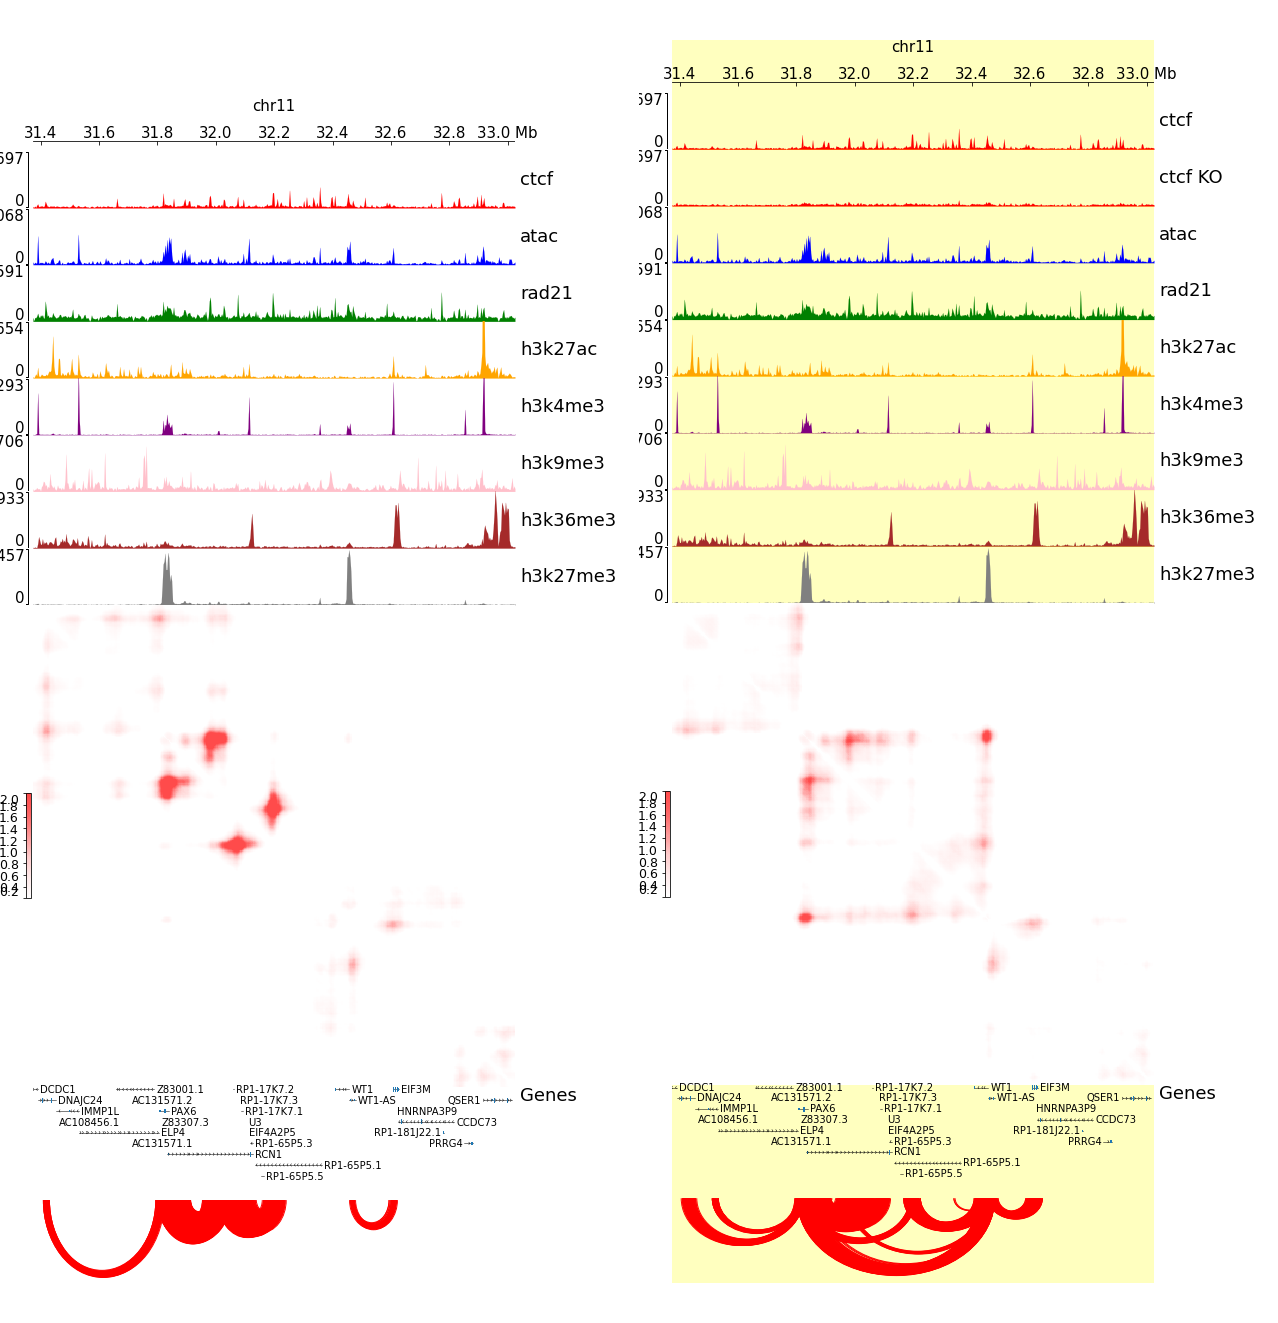

In [23]:
display_images(f'outputs/ctcf_ko_only_{celltype}_{chrom}_{start}_ctcf_pred_tracks.png', 
               f'outputs/ctcf_ko_only_{celltype}_{chrom}_{start}_ctcf_ko_tracks.png')

In [20]:
! python ../src/cshark/inference/perturb.py \
    --celltype $celltype \
    --outname seq_shuffle \
    --chr $chrom \
    --start $start \
    --model $checkpoint \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --latent_size 256 \
    --seq-filter-size 15 \
    --no-recon \
    --region $region \
    --ko-start $start 31810000 32430000 \
    --ko-width 2097152 50000 50000 \
    --ko ctcf h3k27me3 h3k27me3 \
    --ko-mode knockout knockout knockout \
    --peak-height 1.0 \
    --min-val-pred 0.2 \
    --max-val-pred 2.0 \
    --bigwigs $ctcf \
              $atac \
                $rad21 \
                $h3k27ac \
                $h3k4me3 \
                $h3k9me3 \
                $h3k36me3 \
                $h3k27me3 \
    --silent

6


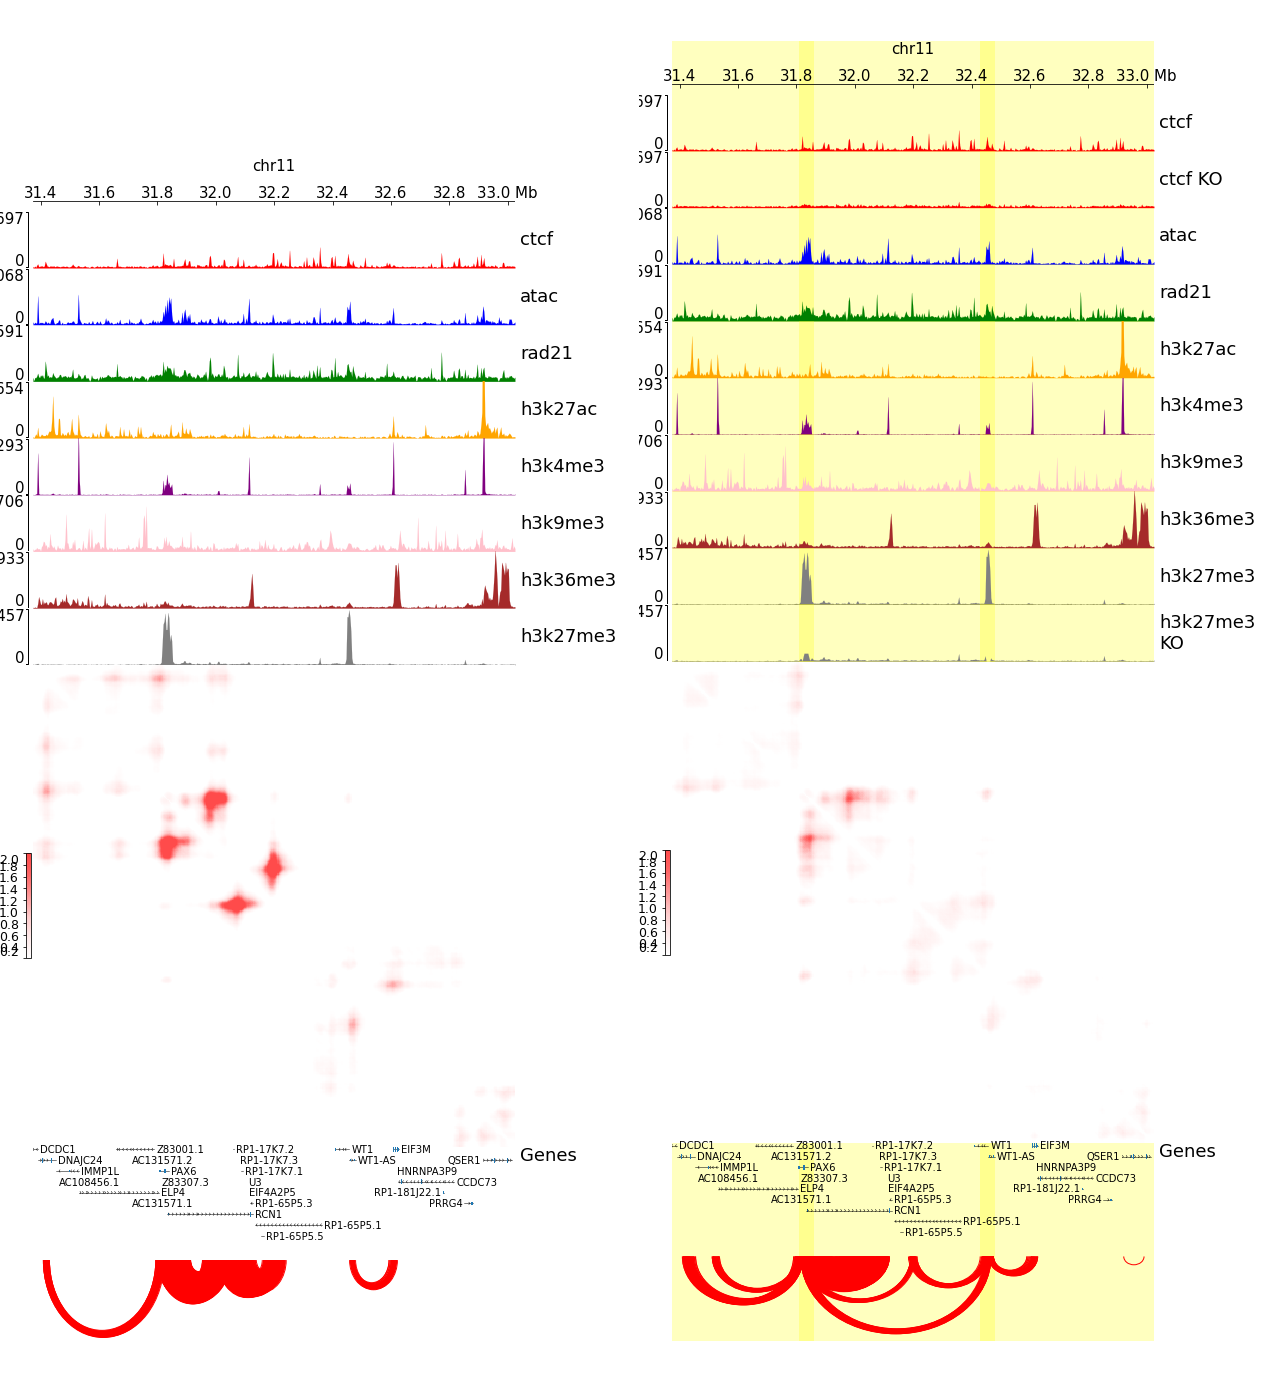

In [21]:
display_images(f'outputs/seq_shuffle_{celltype}_{chrom}_{start}_ctcf_pred_tracks.png', 
               f'outputs/seq_shuffle_{celltype}_{chrom}_{start}_ctcf_ko_tracks.png')

In [11]:
! python ../src/cshark/inference/perturb.py \
    --celltype $celltype \
    --outname h3k27me3 \
    --chr $chrom \
    --start $start \
    --model $checkpoint \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --latent_size 256 \
    --seq-filter-size 15 \
    --no-recon \
    --region $region \
    --ko-start 31810000 32430000 \
    --ko-width 50000 50000 \
    --ko h3k27me3 h3k27me3 \
    --ko-mode knockout knockout \
    --peak-height 1.0 \
    --min-val-pred 0.2 \
    --max-val-pred 1.2 \
    --bigwigs $ctcf \
              $atac \
                $rad21 \
                $h3k27ac \
                $h3k4me3 \
                $h3k9me3 \
                $h3k36me3 \
                $h3k27me3 \
    --silent

6


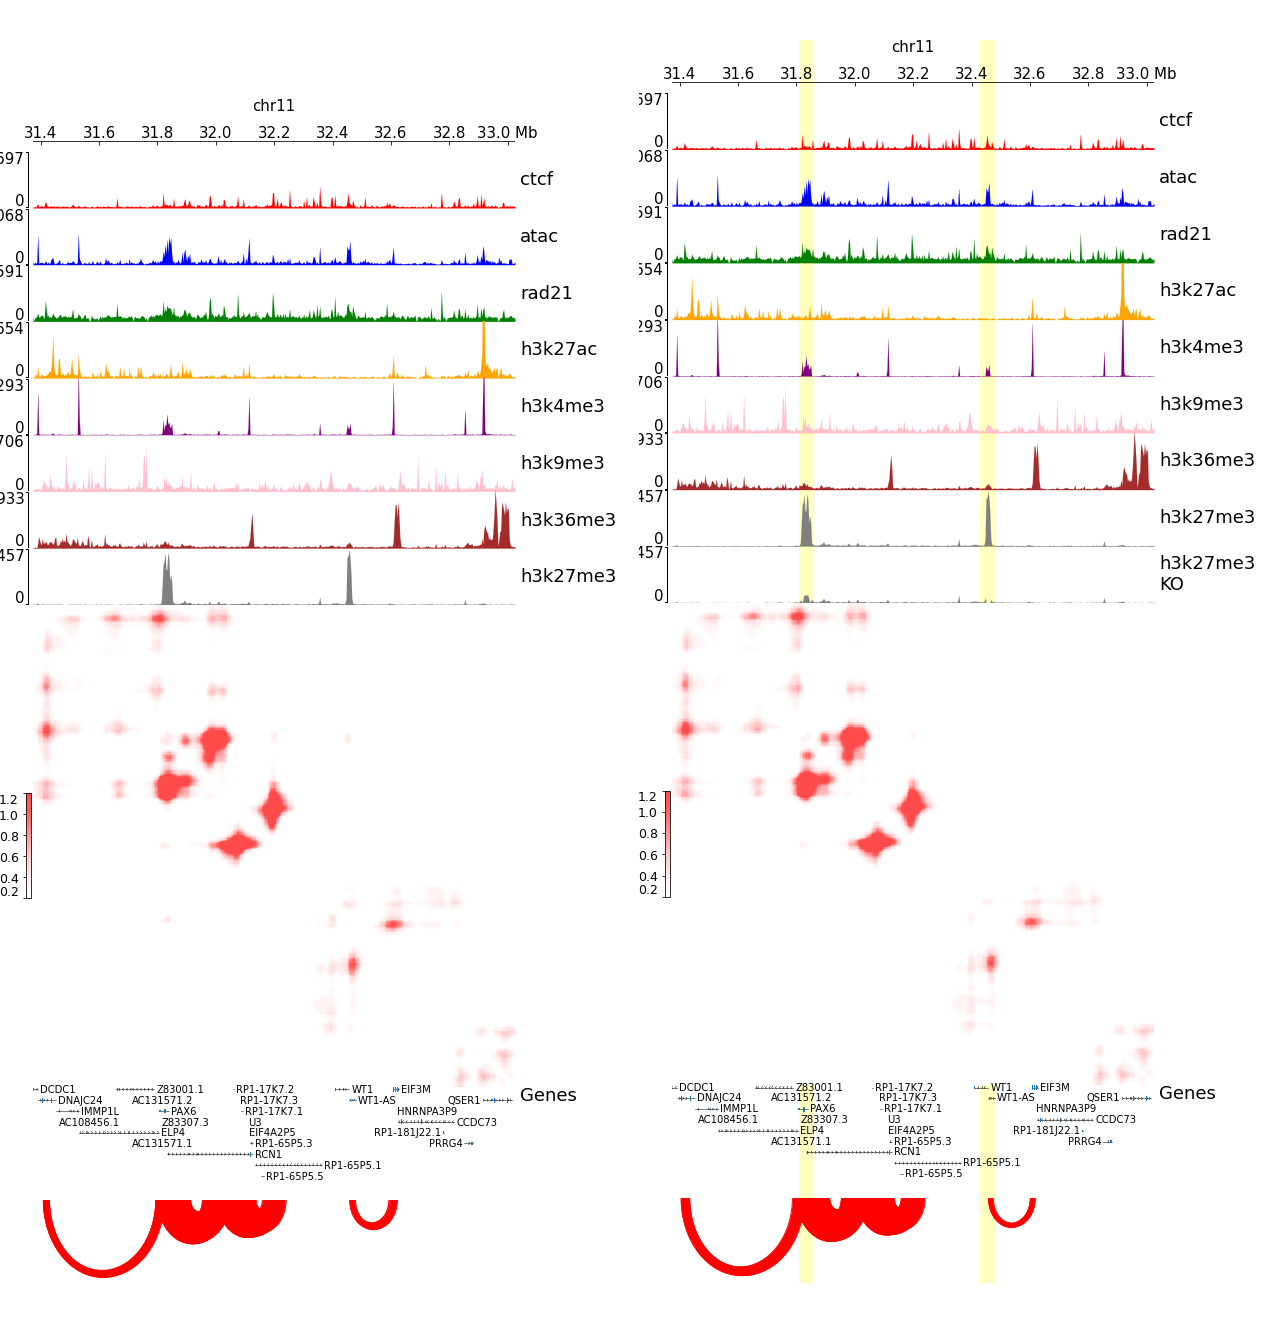

In [12]:
display_images(f'outputs/h3k27me3_{celltype}_{chrom}_{start}_ctcf_pred_tracks.png', 
               f'outputs/h3k27me3_{celltype}_{chrom}_{start}_ctcf_ko_tracks.png')

In [13]:
chrom = 'chr12'
start = 113000000
region = 'chr12:113674023-115079631'

In [14]:
! python ../src/cshark/inference/perturb.py \
    --celltype $celltype \
    --outname baseline \
    --chr $chrom \
    --start $start \
    --model $checkpoint \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --latent_size 256 \
    --seq-filter-size 15 \
    --no-recon \
    --region $region \
    --min-val-pred 0.5 \
    --max-val-pred 2.0 \
    --plot-bigwigs ctcf atac \
    --bigwigs $ctcf \
              $atac \
                $rad21 \
                $h3k27ac \
                $h3k4me3 \
                $h3k9me3 \
                $h3k36me3 \
                $h3k27me3 \
    --silent

6


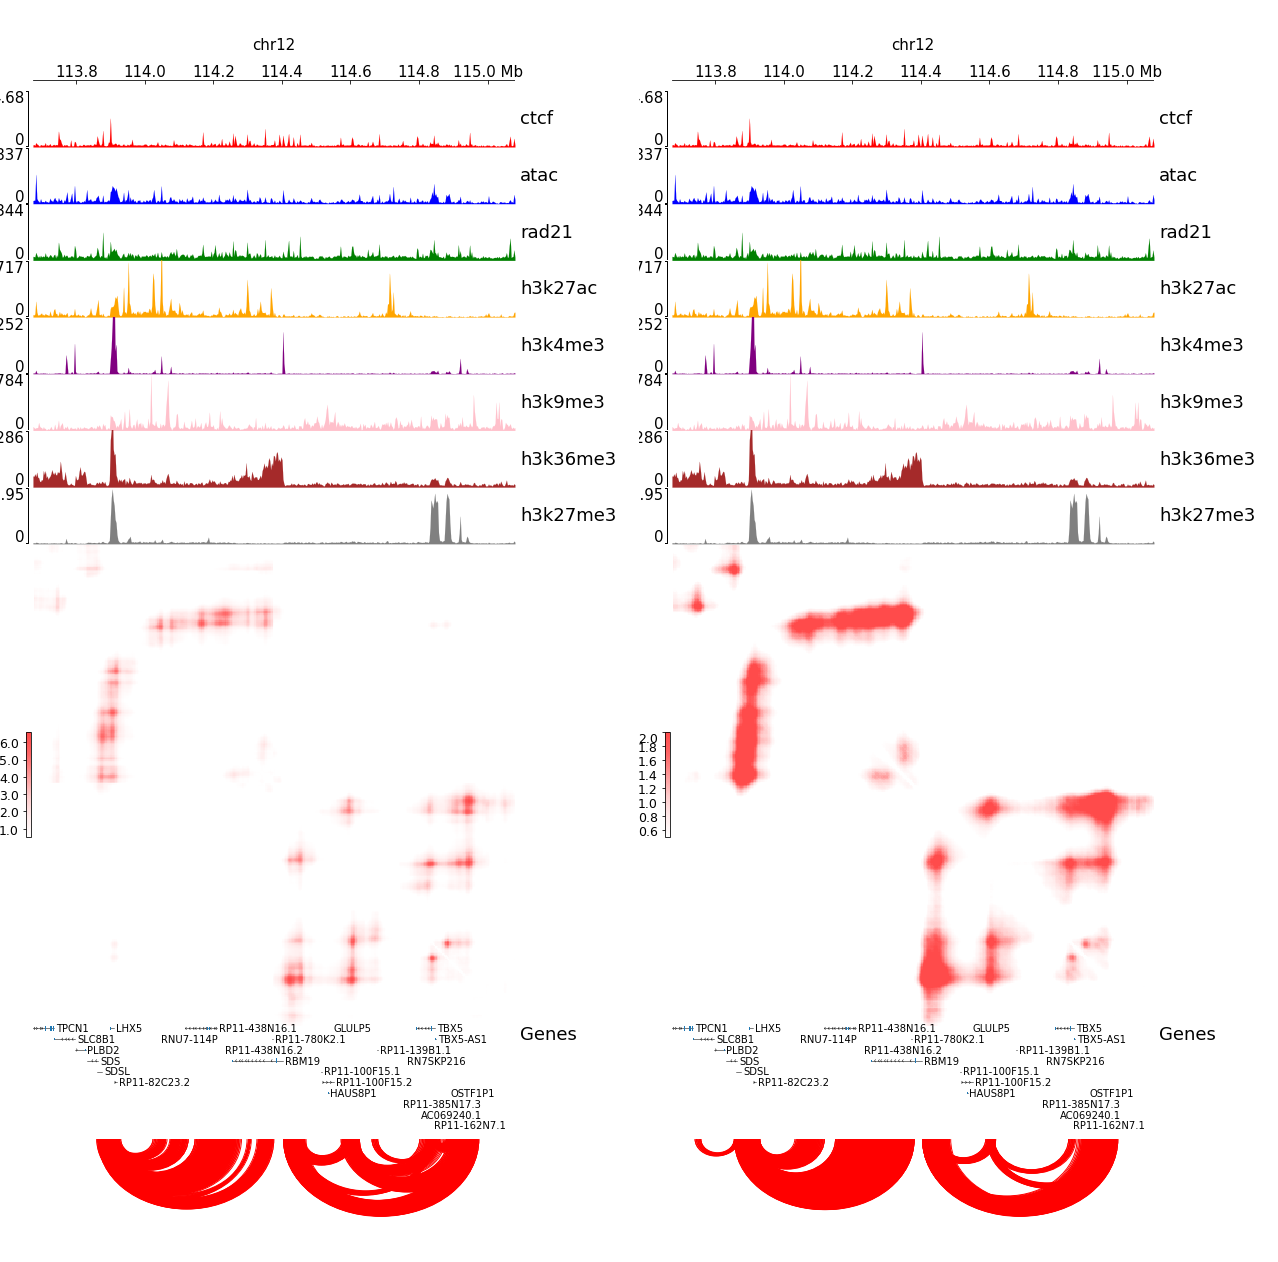

In [15]:
display_images(f'outputs/baseline_{celltype}_{chrom}_{start}_ctcf_true_tracks.png', 
               f'outputs/baseline_{celltype}_{chrom}_{start}_ctcf_pred_tracks.png')

In [16]:
! python ../src/cshark/inference/perturb.py \
    --celltype $celltype \
    --outname ctcf_ko_only \
    --chr $chrom \
    --start $start \
    --model $checkpoint \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --latent_size 256 \
    --seq-filter-size 15 \
    --no-recon \
    --region $region \
    --ko-start $start \
    --ko-width 2097152 \
    --ko ctcf \
    --ko-mode knockout \
    --peak-height 1.0 \
    --min-val-pred 0.0 \
    --max-val-pred 1.1 \
    --plot-bigwigs ctcf atac \
    --bigwigs $ctcf \
              $atac \
                $rad21 \
                $h3k27ac \
                $h3k4me3 \
                $h3k9me3 \
                $h3k36me3 \
                $h3k27me3 \
    --silent

6


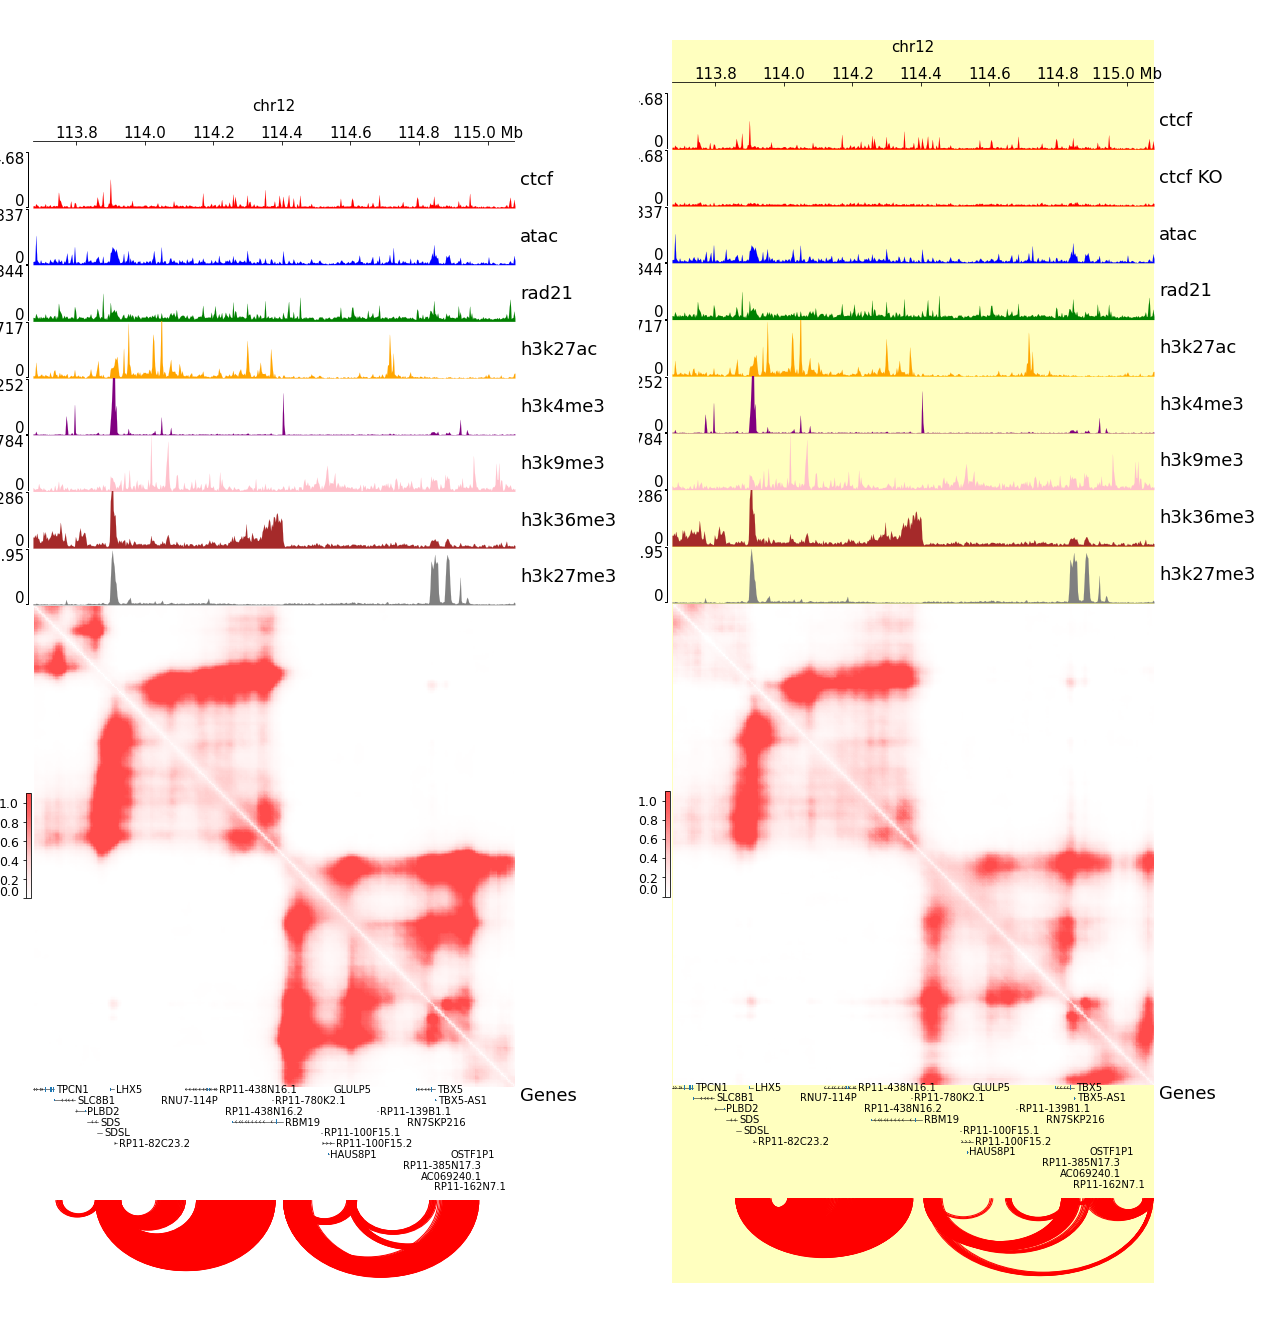

In [17]:
display_images(f'outputs/ctcf_ko_only_{celltype}_{chrom}_{start}_ctcf_pred_tracks.png', 
               f'outputs/ctcf_ko_only_{celltype}_{chrom}_{start}_ctcf_ko_tracks.png')